# 🔐 Production-Level Credit Card Fraud Detection System
### Hybrid: XGBoost + Rule-Based Detection
### Models: Logistic Regression | KNN | Random Forest | XGBoost
### Features: Balance Errors | Money Flow | Ratio Features | Flag Features

## Cell 1 — Install Libraries

In [1]:
# Install all required packages
import subprocess
subprocess.run(['pip', 'install', 'pandas', 'numpy', 'matplotlib', 'seaborn',
                'scikit-learn', 'imbalanced-learn', 'joblib', 'xgboost'], check=True)
print('All libraries installed!')

All libraries installed!


## Cell 2 — Import Libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Sklearn — model training, selection, evaluation
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# SMOTE — oversample minority class
from imblearn.over_sampling import SMOTE

# XGBoost — best model for tabular fraud data
from xgboost import XGBClassifier

# Scipy — for RandomizedSearchCV distributions
from scipy.stats import randint, uniform

print('All libraries loaded!')

All libraries loaded!


## Cell 3 — Load Dataset

In [3]:
# Load 10 lakh rows from the PaySim dataset
# PaySim simulates mobile money transactions — only TRANSFER and CASH_OUT have fraud
FILE_PATH = 'PS_20174392719_1491204439457_log.csv'

print('Loading 10 lakh rows...')
df = pd.read_csv(FILE_PATH, nrows=1000000)

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Loading 10 lakh rows...
Shape: (1000000, 11)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## Cell 4 — Basic EDA (Exploratory Data Analysis)

In [4]:
# Understand the data before touching it
print('--- Shape ---')
print(df.shape)

print('\n--- Missing Values ---')
print(df.isnull().sum())

print('\n--- Duplicate Rows ---')
print(df.duplicated().sum())

print('\n--- Fraud vs Legitimate ---')
print(df['isFraud'].value_counts())
print(f'Fraud %: {df["isFraud"].mean() * 100:.4f}%')

print('\n--- Transaction Types ---')
print(df['type'].value_counts())

print('\n--- Summary Statistics ---')
df.describe()

--- Shape ---
(1000000, 11)

--- Missing Values ---
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

--- Duplicate Rows ---
0

--- Fraud vs Legitimate ---
isFraud
0    999465
1       535
Name: count, dtype: int64
Fraud %: 0.0535%

--- Transaction Types ---
type
CASH_OUT    362676
PAYMENT     329753
CASH_IN     218673
TRANSFER     82424
DEBIT         6474
Name: count, dtype: int64

--- Summary Statistics ---


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1000000.000000,1.000000e+06,1.000000e+06,1.000000e+06,1.000000e+06,1.000000e+06,1000000.000000,1000000.0
mean,25.156387,1.602499e+05,8.776703e+05,8.983465e+05,9.860668e+05,1.125662e+06,0.000535,0.0
std,12.652100,2.592584e+05,2.982420e+06,3.019326e+06,2.305423e+06,2.426587e+06,0.023124,0.0
min,1.000000,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,14.000000,1.275993e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,20.000000,7.953670e+04,1.595700e+04,0.000000e+00,1.349287e+05,2.301105e+05,0.000000,0.0
75%,38.000000,2.166060e+05,1.397520e+05,1.797911e+05,9.268256e+05,1.167926e+06,0.000000,0.0
max,45.000000,1.000000e+07,3.893942e+07,3.894623e+07,4.205466e+07,4.216916e+07,1.000000,0.0


## Cell 5 — EDA Graphs

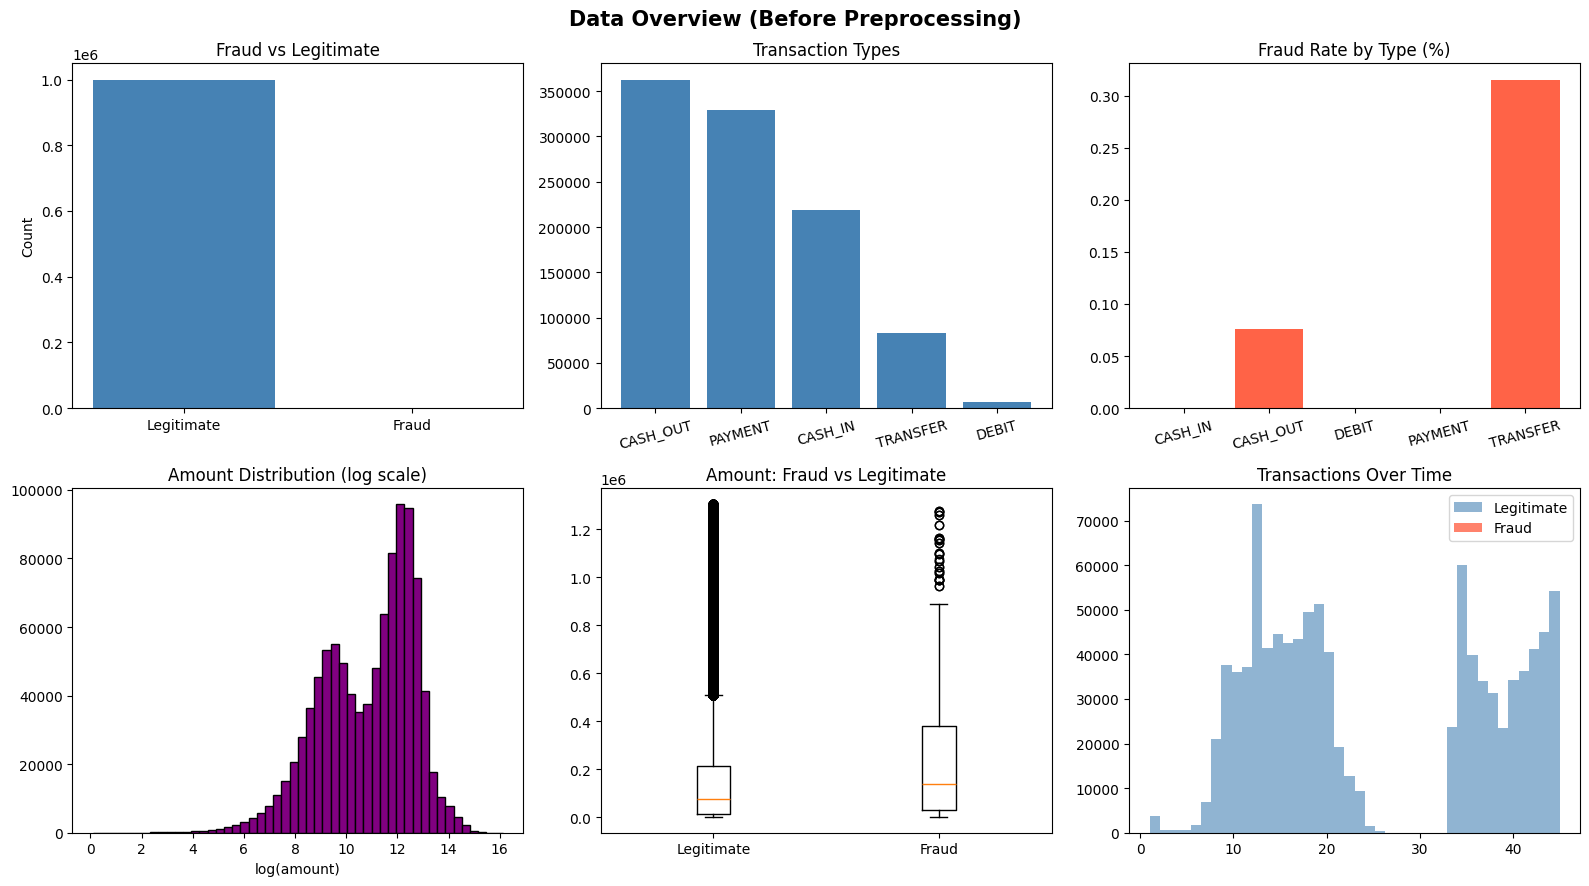

Saved as eda_plots.png


In [5]:
# Visual overview of the dataset before preprocessing
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Data Overview (Before Preprocessing)', fontsize=15, fontweight='bold')

# Graph 1 — Class distribution
counts = df['isFraud'].value_counts()
axes[0][0].bar(['Legitimate', 'Fraud'], counts.values, color=['steelblue', 'tomato'])
axes[0][0].set_title('Fraud vs Legitimate')
axes[0][0].set_ylabel('Count')

# Graph 2 — Transaction type counts
type_counts = df['type'].value_counts()
axes[0][1].bar(type_counts.index, type_counts.values, color='steelblue')
axes[0][1].set_title('Transaction Types')
axes[0][1].tick_params(axis='x', rotation=15)

# Graph 3 — Fraud rate per transaction type
fraud_rate = df.groupby('type')['isFraud'].mean() * 100
axes[0][2].bar(fraud_rate.index, fraud_rate.values, color='tomato')
axes[0][2].set_title('Fraud Rate by Type (%)')
axes[0][2].tick_params(axis='x', rotation=15)

# Graph 4 — Amount distribution
axes[1][0].hist(np.log1p(df['amount']), bins=50, color='purple', edgecolor='black')
axes[1][0].set_title('Amount Distribution (log scale)')
axes[1][0].set_xlabel('log(amount)')

# Graph 5 — Amount boxplot fraud vs legit
limit = df['amount'].quantile(0.99)
legit = df[df['isFraud'] == 0]['amount']
fraud = df[df['isFraud'] == 1]['amount']
axes[1][1].boxplot([legit[legit < limit], fraud[fraud < limit]],
                   labels=['Legitimate', 'Fraud'])
axes[1][1].set_title('Amount: Fraud vs Legitimate')

# Graph 6 — Transactions over time
axes[1][2].hist(df[df['isFraud'] == 0]['step'], bins=40, alpha=0.6,
               color='steelblue', label='Legitimate')
axes[1][2].hist(df[df['isFraud'] == 1]['step'], bins=40, alpha=0.8,
               color='tomato', label='Fraud')
axes[1][2].set_title('Transactions Over Time')
axes[1][2].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120)
plt.show()
print('Saved as eda_plots.png')

## Cell 6 — Correlation Heatmap

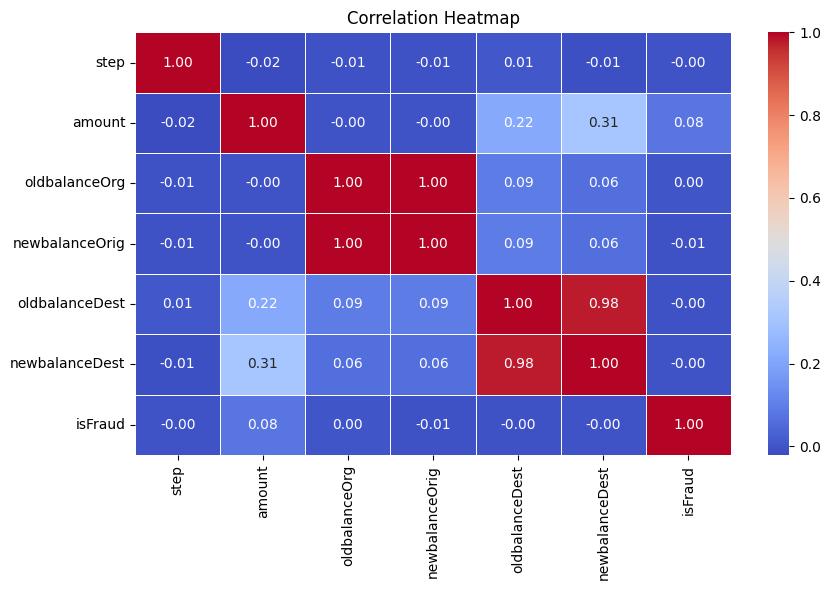

Saved!


In [6]:
# Correlation shows which raw features are most related to isFraud
num_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
            'oldbalanceDest', 'newbalanceDest', 'isFraud']

plt.figure(figsize=(9, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()
print('Saved!')

## Cell 7 — Preprocessing & Advanced Feature Engineering

In [7]:
# ── Step 1: Basic cleaning ────────────────────────────────
df = df.drop_duplicates()
df = df.dropna()

# ── Step 2: Filter to fraud-possible types only ───────────
# Fraud ONLY occurs in TRANSFER and CASH_OUT in this dataset
df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]
print(f'Rows after type filter : {len(df):,}')
print(f'Fraud % now            : {df["isFraud"].mean()*100:.4f}%')

# ── Step 3: Drop useless columns ─────────────────────────
# nameOrig/nameDest are IDs, isFlaggedFraud is a rule-based leakage column
df = df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'])

# ── Step 4: Encode transaction type ──────────────────────
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])
type_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Type encoding:', type_mapping)

# ── Step 5: Advanced Feature Engineering ─────────────────
# These are the MOST IMPORTANT fraud signals

# If sender balance did not drop correctly → money appeared from nowhere
df['errorBalanceOrig'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']

# If receiver balance did not increase correctly → money vanished
df['errorBalanceDest'] = df['newbalanceDest'] - df['oldbalanceDest'] - df['amount']

# Absolute mismatch on sender side
df['sender_balance_error'] = abs(df['errorBalanceOrig'])

# Absolute mismatch on receiver side
df['receiver_balance_error'] = abs(df['errorBalanceDest'])

# Total money flow error — catches duplication AND disappearance
# If this is not 0, money was created or destroyed = definite fraud signal
df['money_flow_error'] = abs(df['errorBalanceOrig']) + abs(df['errorBalanceDest'])

# Ratio of amount to original balance — large ratio = suspicious
df['amount_to_balance_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

# Both destination balances are 0 — receiver account never touched
df['dest_zero_flag'] = ((df['oldbalanceDest'] == 0) & (df['newbalanceDest'] == 0)).astype(int)

# Sender account fully wiped to zero after transaction
df['sender_wiped'] = (df['newbalanceOrig'] == 0).astype(int)

# Large transaction flag — transactions above 200,000 are statistically suspicious
df['large_transaction'] = (df['amount'] > 200000).astype(int)

# Expected balance values — what SHOULD have happened
df['orig_balance_expected'] = df['oldbalanceOrg'] - df['amount']
df['dest_balance_expected'] = df['oldbalanceDest'] + df['amount']

print(f'\nTotal features created: {len(df.columns)}')
print(f'Columns: {df.columns.tolist()}')
print(f'Shape  : {df.shape}')
print('Feature engineering done!')

Rows after type filter : 445,100
Fraud % now            : 0.1202%
Type encoding: {'CASH_OUT': np.int64(0), 'TRANSFER': np.int64(1)}

Total features created: 19
Columns: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'errorBalanceOrig', 'errorBalanceDest', 'sender_balance_error', 'receiver_balance_error', 'money_flow_error', 'amount_to_balance_ratio', 'dest_zero_flag', 'sender_wiped', 'large_transaction', 'orig_balance_expected', 'dest_balance_expected']
Shape  : (445100, 19)
Feature engineering done!


## Cell 8 — Feature Selection (Forced + SelectKBest Hybrid)

All Feature Scores:
                Feature    Score
           sender_wiped 0.082050
      large_transaction 0.058954
                   type 0.010670
  orig_balance_expected 0.008570
amount_to_balance_ratio 0.008387
                   step 0.004886
          oldbalanceOrg 0.002675
   sender_balance_error 0.002541
       errorBalanceOrig 0.002474
         dest_zero_flag 0.002398
                 amount 0.001974
         newbalanceDest 0.001593
       errorBalanceDest 0.001114
         oldbalanceDest 0.000874
       money_flow_error 0.000608
  dest_balance_expected 0.000598
 receiver_balance_error 0.000372
         newbalanceOrig 0.000100


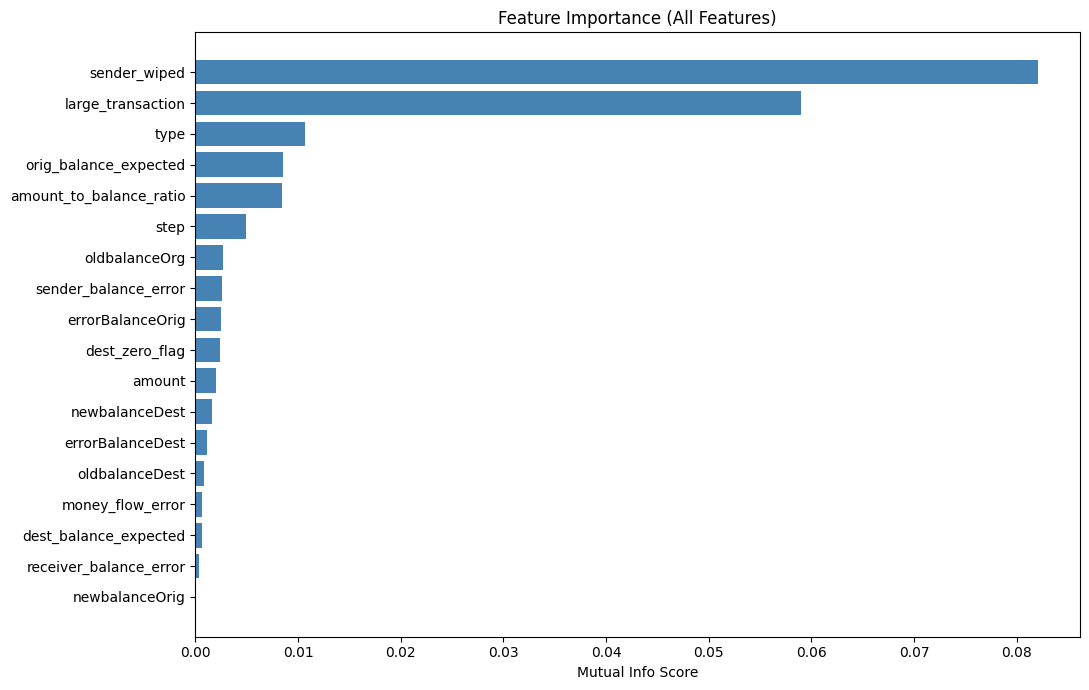


Forced features   : ['errorBalanceOrig', 'errorBalanceDest', 'money_flow_error', 'sender_balance_error', 'receiver_balance_error', 'dest_zero_flag', 'sender_wiped', 'amount_to_balance_ratio']
Auto-selected     : ['large_transaction', 'type', 'orig_balance_expected', 'step', 'oldbalanceOrg']
Final features    : ['errorBalanceOrig', 'errorBalanceDest', 'money_flow_error', 'sender_balance_error', 'receiver_balance_error', 'dest_zero_flag', 'sender_wiped', 'amount_to_balance_ratio', 'large_transaction', 'type', 'orig_balance_expected', 'step', 'oldbalanceOrg']
Total features    : 13


In [8]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

# ── FORCED features — these MUST always be included ──────
# These are the strongest fraud signals — never let SelectKBest drop them
FORCED_FEATURES = [
    'errorBalanceOrig',
    'errorBalanceDest',
    'money_flow_error',
    'sender_balance_error',
    'receiver_balance_error',
    'dest_zero_flag',
    'sender_wiped',
    'amount_to_balance_ratio'
]

# ── SelectKBest on remaining features ────────────────────
# Run SelectKBest on all features but only add non-forced ones
selector = SelectKBest(score_func=mutual_info_classif, k='all')
selector.fit(X, y)

# Show all feature scores
scores = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_})
scores = scores.sort_values('Score', ascending=False)
print('All Feature Scores:')
print(scores.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(11, 7))
plt.barh(scores['Feature'][::-1], scores['Score'][::-1], color='steelblue')
plt.xlabel('Mutual Info Score')
plt.title('Feature Importance (All Features)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()

# Top 5 from SelectKBest that are NOT already in forced list
top_auto = [f for f in scores['Feature'].tolist() if f not in FORCED_FEATURES][:5]

# Final feature list = forced + top auto-selected
selected_features = FORCED_FEATURES + top_auto

# Remove duplicates while preserving order
seen = set()
selected_features = [f for f in selected_features if not (f in seen or seen.add(f))]

print(f'\nForced features   : {FORCED_FEATURES}')
print(f'Auto-selected     : {top_auto}')
print(f'Final features    : {selected_features}')
print(f'Total features    : {len(selected_features)}')

X = X[selected_features]

## Cell 9 — Train-Test Split + Scaling + SMOTE

Train : 356,080  |  Test: 89,020
Fraud in train: 428 (0.120%)
Scaling done

Running SMOTE...
After SMOTE — Train: 444,565  |  Fraud: 88,913


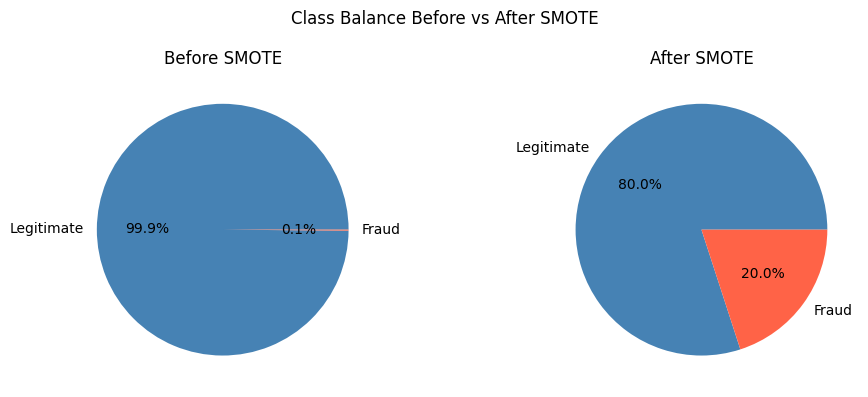

Done!


In [9]:
# ── Train-Test Split ──────────────────────────────────────
# stratify=y ensures same fraud % in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Fraud in train: {y_train.sum()} ({y_train.mean()*100:.3f}%)')

# ── StandardScaler ────────────────────────────────────────
# Normalises all features to same scale
# IMPORTANT: fit only on training data, apply on both
# Keeping as DataFrame preserves column names (prevents sklearn warning)
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)
print('Scaling done')

# ── SMOTE ─────────────────────────────────────────────────
# Creates synthetic fraud samples to balance dataset
# sampling_strategy=0.3 means: for every 10 legit, create 3 fraud
# Applied ONLY on training data — never on test data
print('\nRunning SMOTE...')
smote = SMOTE(sampling_strategy=0.25, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)
X_train_res = pd.DataFrame(X_train_res, columns=X_train.columns)
y_train_res = pd.Series(y_train_res).reset_index(drop=True)
print(f'After SMOTE — Train: {len(X_train_res):,}  |  Fraud: {y_train_res.sum():,}')

# Visualise class balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
before = pd.Series(y_train).value_counts().sort_index()
axes[0].pie(before.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[0].set_title('Before SMOTE')
after = y_train_res.value_counts().sort_index()
axes[1].pie(after.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1].set_title('After SMOTE')
plt.suptitle('Class Balance Before vs After SMOTE')
plt.tight_layout()
plt.savefig('smote_balance.png', dpi=120)
plt.show()
print('Done!')


## Cell 10 — Prepare Sample for Hyperparameter Tuning

In [10]:
# Use 50,000 rows for fast tuning — still representative of full data
print('Preparing 70,000 row sample for hyperparameter tuning...')
sample_idx  = X_train_res.sample(n=70000, random_state=42).index
X_sample    = X_train_res.loc[sample_idx].reset_index(drop=True)
y_sample    = y_train_res.loc[sample_idx].reset_index(drop=True)
print(f'Sample shape: {X_sample.shape}')
print(f'Fraud in sample: {y_sample.sum()} ({y_sample.mean()*100:.1f}%)')

Preparing 70,000 row sample for hyperparameter tuning...
Sample shape: (70000, 13)
Fraud in sample: 14161 (20.2%)


## Cell 11 — XGBoost Hyperparameter Tuning (RandomizedSearchCV)

In [11]:
# ✅ Correct scale_pos_weight (use ORIGINAL data)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = round(neg / pos)

print(f'scale_pos_weight = {spw}')

# Parameter space
xgb_param_dist = {
    'n_estimators'    : randint(200, 500),
    'max_depth'       : randint(4, 10),
    'learning_rate'   : uniform(0.01, 0.2),
    'subsample'       : uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma'           : uniform(0, 0.5),
    'min_child_weight': randint(1, 10)
}

# Base model
xgb_base = XGBClassifier(
    scale_pos_weight = spw,
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1
)

# Random search
xgb_search = RandomizedSearchCV(
    estimator           = xgb_base,
    param_distributions = xgb_param_dist,
    n_iter              = 20,
    scoring             = 'precision',
    cv                  = 3,
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1
)

print('Running tuning...')
xgb_search.fit(X_train_res, y_train_res)  

print('\nBest Parameters:', xgb_search.best_params_)
print('Best F1 Score  :', round(xgb_search.best_score_, 4))

scale_pos_weight = 831
Running tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters: {'colsample_bytree': np.float64(0.7297380084021096), 'gamma': np.float64(0.061043977350336676), 'learning_rate': np.float64(0.08125956761539498), 'max_depth': 9, 'min_child_weight': 1, 'n_estimators': 482, 'subsample': np.float64(0.7708431154505025)}
Best F1 Score  : 0.9869


## Cell 12 — Random Forest Hyperparameter Tuning

In [12]:
from sklearn.model_selection import RandomizedSearchCV as RSCV

rf_param_dist = {
    'n_estimators' : randint(100, 300),
    'max_depth'    : randint(8, 25),
    'class_weight' : [{0:1, 1:10}, {0:1, 1:15}, {0:1, 1:20}]
}

rf_search = RSCV(
    estimator           = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions = rf_param_dist,
    n_iter              = 10,
    scoring             = 'f1',
    cv                  = 3,
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1
)

print('Running RandomizedSearchCV for Random Forest...')
rf_search.fit(X_sample, y_sample)
print('\nBest RF Parameters:', rf_search.best_params_)
print('Best F1 Score      :', round(rf_search.best_score_, 4))

Running RandomizedSearchCV for Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best RF Parameters: {'class_weight': {0: 1, 1: 15}, 'max_depth': 19, 'n_estimators': 188}
Best F1 Score      : 0.9904


## Cell 13 — Train All Final Models on Full SMOTE Data

In [13]:
# Use best params found by tuning — train on FULL SMOTE training data
best_xgb_params = xgb_search.best_params_
best_rf_params  = rf_search.best_params_

print('Best XGBoost params:', best_xgb_params)
print('Best RF params     :', best_rf_params)

models = {

    # Logistic Regression — linear baseline model
    'Logistic Regression': LogisticRegression(
        max_iter     = 1000,
        C            = 1.0,
        class_weight = {0:1, 1:10},
        random_state = 42
    ),

    # KNN — distance based model
    'KNN': KNeighborsClassifier(
        n_neighbors = 5,
        weights     = 'distance',
        metric      = 'euclidean'
    ),

    # Random Forest — ensemble of decision trees
    'Random Forest': RandomForestClassifier(
        n_estimators = best_rf_params['n_estimators'],
        max_depth    = best_rf_params['max_depth'],
        class_weight = best_rf_params['class_weight'],
        random_state = 42,
        n_jobs       = -1
    ),

    # XGBoost — gradient boosting, best for fraud
    'XGBoost': XGBClassifier(
        n_estimators     = best_xgb_params['n_estimators'],
        max_depth        = best_xgb_params['max_depth'],
        learning_rate    = best_xgb_params['learning_rate'],
        subsample        = best_xgb_params['subsample'],
        colsample_bytree = best_xgb_params['colsample_bytree'],
        gamma            = best_xgb_params['gamma'],
        min_child_weight = best_xgb_params['min_child_weight'],
        scale_pos_weight = spw,
        eval_metric      = 'logloss',
        random_state     = 42,
        n_jobs           = -1
    )
}

trained_models = {}
for name, model in models.items():
    print(f'Training {name}...', end=' ')
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model
    print('Done!')

print('\nAll models trained with best parameters!')

Best XGBoost params: {'colsample_bytree': np.float64(0.7297380084021096), 'gamma': np.float64(0.061043977350336676), 'learning_rate': np.float64(0.08125956761539498), 'max_depth': 9, 'min_child_weight': 1, 'n_estimators': 482, 'subsample': np.float64(0.7708431154505025)}
Best RF params     : {'class_weight': {0: 1, 1: 15}, 'max_depth': 19, 'n_estimators': 188}
Done!ing Logistic Regression... 
Training KNN... Done!
Done!ing Random Forest... 
Done!ing XGBoost... 

All models trained with best parameters!


## Cell 14 — Find Best Probability Threshold for XGBoost

 Threshold  Precision  Recall  F1-Score
      0.20     0.2141  0.9626    0.3503
      0.25     0.2244  0.9626    0.3640
      0.30     0.2330  0.9626    0.3752
      0.35     0.2384  0.9626    0.3822
      0.40     0.2447  0.9626    0.3902
      0.45     0.2525  0.9626    0.4000
      0.50     0.2581  0.9626    0.4071
      0.55     0.2661  0.9626    0.4170
      0.60     0.2711  0.9626    0.4230
      0.65     0.2769  0.9626    0.4301
      0.70     0.2845  0.9626    0.4392

Best Threshold: 0.7


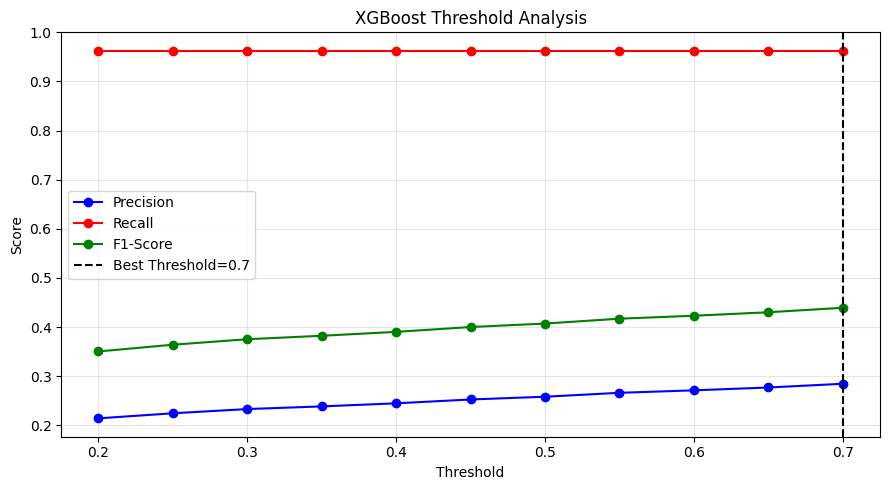

In [14]:
# Default threshold is 0.5 — but for fraud detection lowering it catches more fraud
# We test thresholds from 0.2 to 0.7 and pick the one with best F1 score

xgb_model  = trained_models['XGBoost']
y_prob_xgb = xgb_model.predict_proba(X_test_sc)[:, 1]

thresholds = np.arange(0.2, 0.75, 0.05)
results_thresh = []

for thresh in thresholds:
    y_pred_t = (y_prob_xgb >= thresh).astype(int)
    results_thresh.append({
        'Threshold': round(thresh, 2),
        'Precision': round(precision_score(y_test, y_pred_t), 4),
        'Recall'   : round(recall_score(y_test, y_pred_t), 4),
        'F1-Score' : round(f1_score(y_test, y_pred_t), 4)
    })

thresh_df = pd.DataFrame(results_thresh)
print(thresh_df.to_string(index=False))

# Pick threshold with best F1
best_threshold = thresh_df.loc[thresh_df['F1-Score'].idxmax(), 'Threshold']
print(f'\nBest Threshold: {best_threshold}')

# Plot threshold analysis
plt.figure(figsize=(9, 5))
plt.plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', label='Precision')
plt.plot(thresh_df['Threshold'], thresh_df['Recall'],    'r-o', label='Recall')
plt.plot(thresh_df['Threshold'], thresh_df['F1-Score'],  'g-o', label='F1-Score')
plt.axvline(x=best_threshold, color='black', linestyle='--', label=f'Best Threshold={best_threshold}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('XGBoost Threshold Analysis')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=120)
plt.show()

## Cell 15 — Evaluation Metrics (All Models)

In [15]:
# Evaluate all 4 models on the test set
# For XGBoost we use the best threshold found in Cell 14
results = []

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test_sc)[:, 1]

    # Use best threshold for XGBoost, default 0.5 for others
    if name == 'XGBoost':
        y_pred = (y_prob >= best_threshold).astype(int)
    else:
        y_pred = model.predict(X_test_sc)

    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1-Score' : round(f1_score(y_test, y_pred), 4),
        'AUC-ROC'  : round(roc_auc_score(y_test, y_prob), 4)
    })

results_df = pd.DataFrame(results)
print('='*70)
print('MODEL EVALUATION RESULTS')
print('='*70)
print(results_df.to_string(index=False))
print('='*70)

best = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
print(f'\nBest Model (by F1-Score): {best}')

MODEL EVALUATION RESULTS
              Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.8443     0.0073  0.9533    0.0145   0.9750
                KNN    0.9963     0.2219  0.8131    0.3487   0.9099
      Random Forest    0.9967     0.2634  0.9626    0.4137   0.9791
            XGBoost    0.9970     0.2845  0.9626    0.4392   0.9888

Best Model (by F1-Score): XGBoost


## Cell 16 — Confusion Matrices

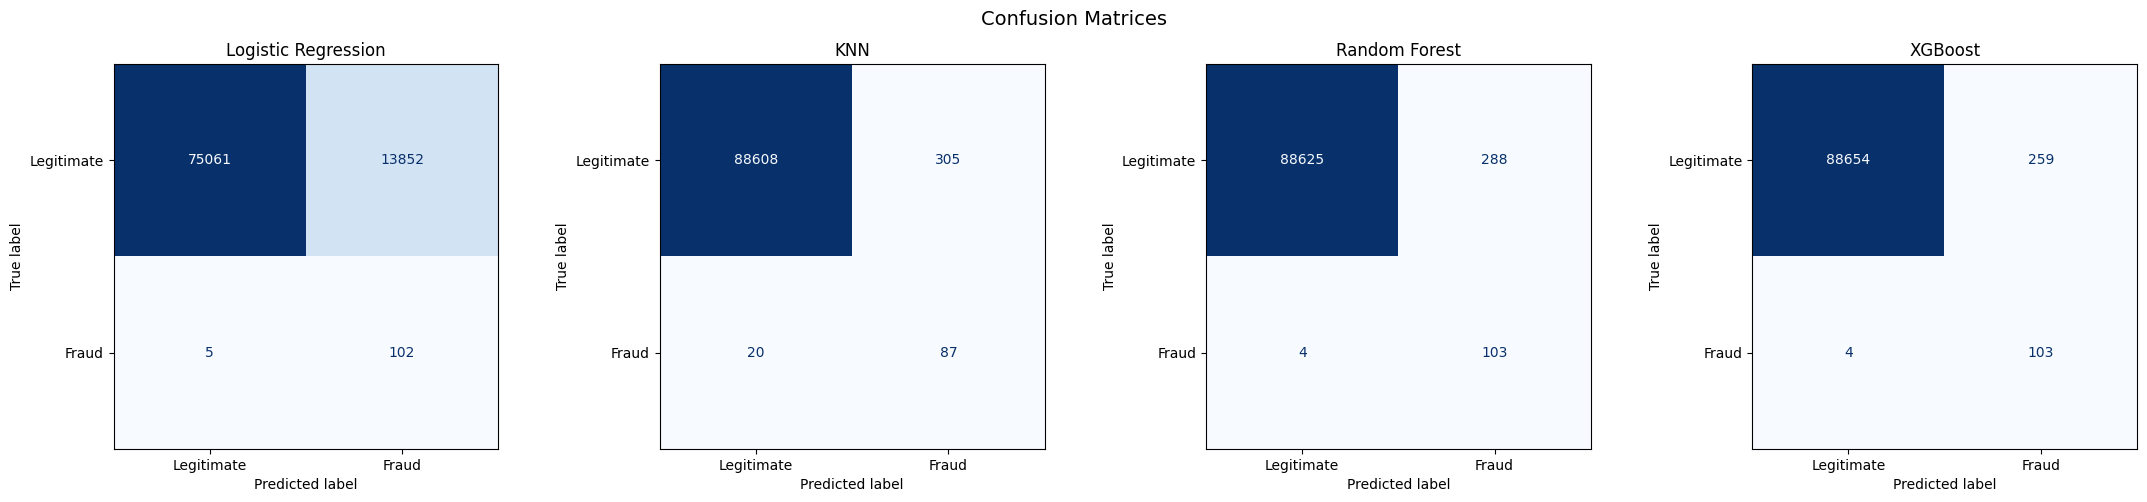

Saved!


In [16]:
# Confusion matrix shows: TP, FP, TN, FN
# False Negatives (fraud missed) are the most costly in banking

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Confusion Matrices', fontsize=14)

for ax, (name, model) in zip(axes, trained_models.items()):
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    if name == 'XGBoost':
        y_pred = (y_prob >= best_threshold).astype(int)
    else:
        y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraud']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(name)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120)
plt.show()
print('Saved!')

## Cell 17 — ROC Curves

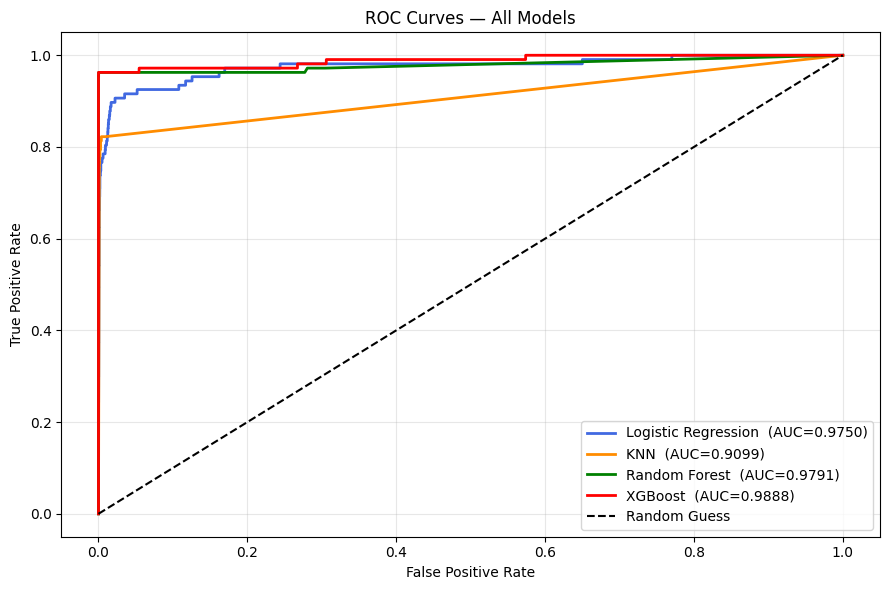

Saved!


In [17]:
# AUC = 1.0 is perfect, 0.5 is random guessing
# Higher AUC = better separation between fraud and legit

plt.figure(figsize=(9, 6))
colors = ['royalblue', 'darkorange', 'green', 'red']

for (name, model), color in zip(trained_models.items(), colors):
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC={auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120)
plt.show()
print('Saved!')

## Cell 18 — Classification Reports

In [18]:
for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    if name == 'XGBoost':
        y_pred = (y_prob >= best_threshold).astype(int)
    else:
        y_pred = model.predict(X_test_sc)
    print(f'\n{"-"*55}')
    print(f'  {name}')
    print(f'{"-"*55}')
    print(classification_report(y_test, y_pred,
                                target_names=['Legitimate', 'Fraud']))


-------------------------------------------------------
  Logistic Regression
-------------------------------------------------------
              precision    recall  f1-score   support

  Legitimate       1.00      0.84      0.92     88913
       Fraud       0.01      0.95      0.01       107

    accuracy                           0.84     89020
   macro avg       0.50      0.90      0.47     89020
weighted avg       1.00      0.84      0.91     89020


-------------------------------------------------------
  KNN
-------------------------------------------------------
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     88913
       Fraud       0.22      0.81      0.35       107

    accuracy                           1.00     89020
   macro avg       0.61      0.90      0.67     89020
weighted avg       1.00      1.00      1.00     89020


-------------------------------------------------------
  Random Forest
-------------------

## Cell 19 — Model Comparison Chart

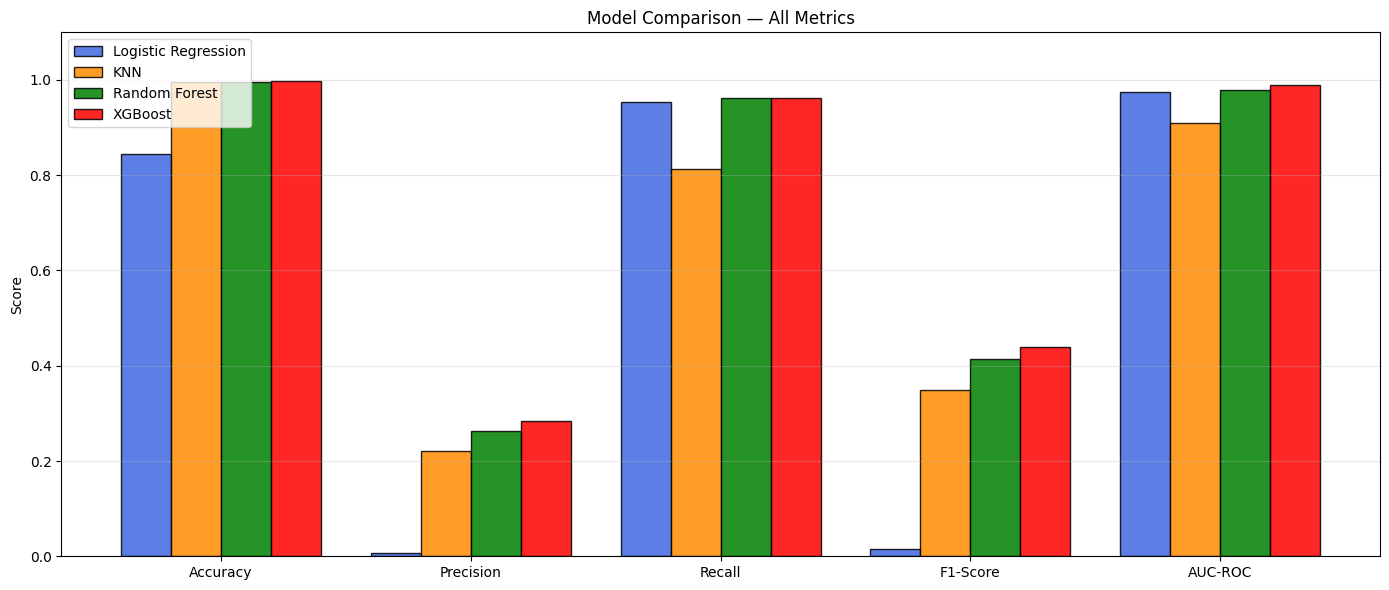

Saved!


In [19]:
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x         = np.arange(len(metrics))
bar_width = 0.2
colors    = ['royalblue', 'darkorange', 'green', 'red']

fig, ax = plt.subplots(figsize=(14, 6))
for i, row in results_df.iterrows():
    vals = [row[m] for m in metrics]
    ax.bar(x + i * bar_width, vals, bar_width,
           label=row['Model'], color=colors[i], edgecolor='black', alpha=0.85)

ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120)
plt.show()
print('Saved!')

## Cell 20 — Save Full Pipeline to Pickle

In [20]:
# Save everything needed to reproduce predictions
pipeline = {
    'models'           : trained_models,      # all 4 trained models
    'scaler'           : scaler,              # StandardScaler fitted on training
    'label_encoder'    : le,                  # LabelEncoder for type column
    'selected_features': selected_features,  # feature list in correct order
    'best_model'       : best,               # name of best performing model
    'best_threshold'   : float(best_threshold), # optimal probability threshold
    'type_mapping'     : type_mapping        # text type → encoded number
}

joblib.dump(pipeline, 'fraud_detection_pipeline.pkl')
print('Pipeline saved to fraud_detection_pipeline.pkl')
print(f'Best model    : {best}')
print(f'Best threshold: {best_threshold}')
print('Now run: python3 predict_fraud.py')

Pipeline saved to fraud_detection_pipeline.pkl
Best model    : XGBoost
Best threshold: 0.7
Now run: python3 predict_fraud.py
